# FrozenLake: Watching Value Propagate

This notebook makes the Bellman update visible.

We will:

1. Start with **deterministic FrozenLake** (`is_slippery=False`).
2. Render the environment so we can see the actual grid.
3. Start with \(V(s)=0\).
4. Apply Bellman optimality updates **one sweep at a time**.
5. Draw the value directly inside every square.
6. Extract the greedy policy.
7. Finally turn on **slippery dynamics** and repeat the same experiment.

The point is not to hide the algorithm behind a library. We want to **watch value propagate backward from the goal**.

In [ ]:
# Colab setup
!pip -q install "gymnasium[toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 25.8 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from PIL import Image

## 1. Start with a deterministic lake

For the first experiment we disable slipping.

That means: if the agent chooses RIGHT, it moves RIGHT.

This lets us understand the Bellman update without adding uncertainty yet.

Number of states : 16
Number of actions: 4
Actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP


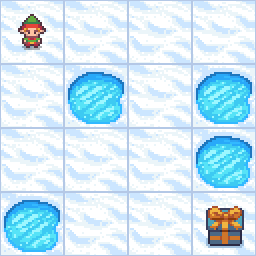

In [ ]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

state, info = env.reset()

print("Number of states :", env.observation_space.n)
print("Number of actions:", env.action_space.n)
print("Actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")

display(Image.fromarray(env.render()))

The standard 4×4 map is:

```text
S F F F
F H F H
F F F H
H F F G
```

- **S** = start
- **F** = frozen surface
- **H** = hole
- **G** = goal

## 2. Look at the transition model

FrozenLake exposes its transition model through `env.unwrapped.P`.

For each state and action it contains tuples:

```text
(probability, next_state, reward, terminated)
```

In the deterministic lake, each action normally has one possible outcome.

In [ ]:
# Example: inspect transitions from state 0 (the start)
for action, outcomes in env.unwrapped.P[0].items():
    print(f"Action {action}: {outcomes}")

Action 0: [(1.0, 0, 0, False)]
Action 1: [(1.0, 4, 0, False)]
Action 2: [(1.0, 1, 0, False)]
Action 3: [(1.0, 0, 0, False)]


:## 3. Value iteration

Bellman optimality:

$V_{k+1}(s)
=
\max_a
\sum_{s',r}
P(s',r\mid s,a)
\left[r+\gamma V_k(s')\right]
$



In [ ]:
gamma = 0.90

n_states = env.observation_space.n
n_actions = env.action_space.n

# Initially the agent knows nothing.
V = np.zeros(n_states)

V.reshape(4, 4)
V

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 4. A plotting function that writes the value inside every square

The color gives a quick visual impression.

The **number inside the cell is the actual value**.

Holes and the goal are labeled explicitly.

In [ ]:
def show_values(V, env, title="State values"):
    desc = env.unwrapped.desc
    rows, cols = desc.shape
    grid = V.reshape(rows, cols)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(grid, vmin=0, vmax=max(1.0, float(np.max(grid))))

    for r in range(rows):
        for c in range(cols):
            tile = desc[r, c].decode("utf-8")
            value = grid[r, c]

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = f"G\n{value:.3f}"
            elif tile == "S":
                label = f"S\n{value:.3f}"
            else:
                label = f"{value:.3f}"

            ax.text(c, r, label, ha="center", va="center", fontsize=14)

    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
    ax.grid(which="minor", linewidth=2)
    ax.tick_params(which="both", length=0)

    ax.set_title(title)
    plt.show()

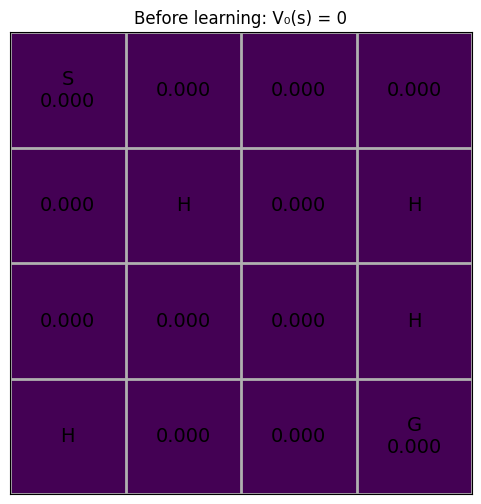

In [ ]:
show_values(V, env, "Before learning: V₀(s) = 0")

## 5. One Bellman sweep

This function performs **exactly one** value-iteration sweep.

Notice that we use a separate `new_V`.

That means every state in sweep \(k+1\) is calculated from the same previous vector \(V_k\).

In [ ]:
def bellman_sweep(env, V, gamma=0.90):
    new_V = V.copy()

    for s in range(env.observation_space.n):

        action_values = []

        for a in range(env.action_space.n):
            q = 0.0

            for prob, next_state, reward, terminated in env.unwrapped.P[s][a]:

                future_value = 0.0 if terminated else V[next_state]

                q += prob * (
                    reward + gamma * future_value
                )

            action_values.append(q)

        new_V[s] = max(action_values)

    return new_V

Now apply **one sweep at a time**.

Watch what happens near the goal first.

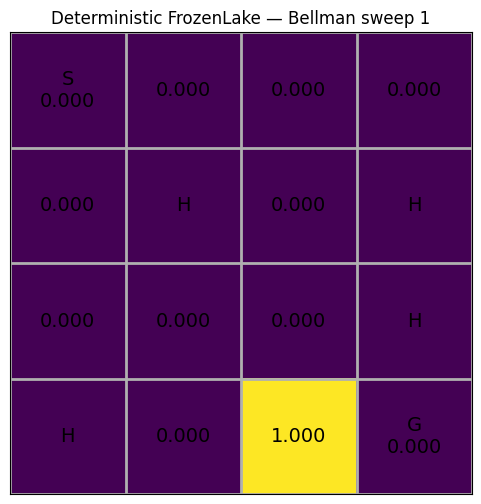

In [ ]:
V = np.zeros(n_states)

for sweep in range(1, 2):
    V = bellman_sweep(env, V, gamma)
    show_values(V, env, f"Deterministic FrozenLake — Bellman sweep {sweep}")

### What are we seeing?

The goal reward first affects states that can reach the goal in one action.

Then those states acquire value.

On the next sweep, **their value affects their neighbors**.

With $(\gamma=0.9)$, in the deterministic case we can visibly recognize values such as

$
1,\quad 0.9,\quad 0.9^2,\quad 0.9^3,\ldots
$

moving backward through the grid.

##This is the intuition behind **value propagation**.

## 6. Iterate until the values stop changing

Converged after 7 sweeps


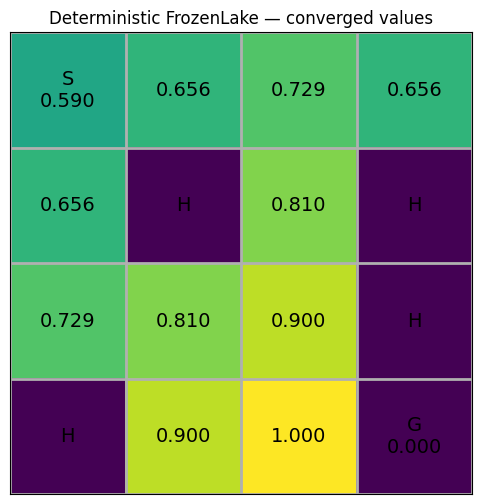

In [ ]:
def value_iteration(env, gamma=0.90, tolerance=1e-10, max_sweeps=1000):
    V = np.zeros(env.observation_space.n)

    history = [V.copy()]

    for sweep in range(max_sweeps):
        new_V = bellman_sweep(env, V, gamma)
        history.append(new_V.copy())

        delta = np.max(np.abs(new_V - V))
        V = new_V

        if delta < tolerance:
            break

    return V, history

V_det, history_det = value_iteration(env, gamma)

print("Converged after", len(history_det) - 1, "sweeps")
show_values(V_det, env, "Deterministic FrozenLake — converged values")

## 7. Extract the greedy policy

Once we know \(V(s)\), we can ask:

> Which action leads to the largest expected return?

That gives us a greedy policy.

In [ ]:
ACTION_SYMBOLS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

def greedy_policy(env, V, gamma=0.90):
    policy = np.zeros(env.observation_space.n, dtype=int)

    for s in range(env.observation_space.n):
        action_values = []

        for a in range(env.action_space.n):
            q = 0.0

            for prob, next_state, reward, terminated in env.unwrapped.P[s][a]:
                future_value = 0.0 if terminated else V[next_state]
                q += prob * (reward + gamma * future_value)

            action_values.append(q)

        policy[s] = int(np.argmax(action_values))

    return policy

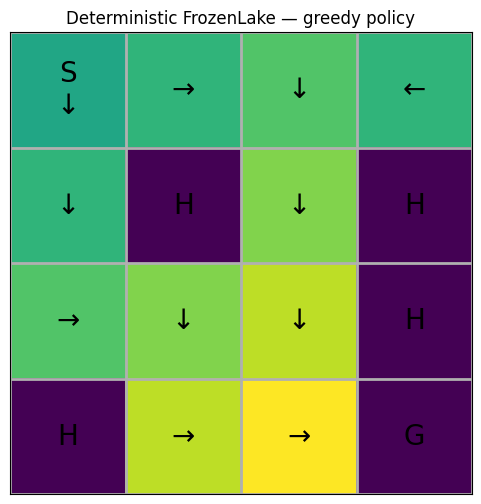

In [ ]:
def show_policy(env, policy, V=None, title="Greedy policy"):
    desc = env.unwrapped.desc
    rows, cols = desc.shape

    background = np.zeros((rows, cols))
    if V is not None:
        background = V.reshape(rows, cols)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(background, vmin=0, vmax=max(1.0, float(background.max())))

    for r in range(rows):
        for c in range(cols):
            s = r * cols + c
            tile = desc[r, c].decode("utf-8")

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = "S\n" + ACTION_SYMBOLS[policy[s]]
            else:
                label = ACTION_SYMBOLS[policy[s]]

            ax.text(c, r, label, ha="center", va="center", fontsize=20)

    ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
    ax.grid(which="minor", linewidth=2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(which="both", length=0)
    ax.set_title(title)
    plt.show()

policy_det = greedy_policy(env, V_det, gamma)
show_policy(env, policy_det, V_det, "Deterministic FrozenLake — greedy policy")

## 8. Run the learned policy and render it

Now the values become behavior.

We render every state so the path is visible.

Steps: 6
Reward: 1


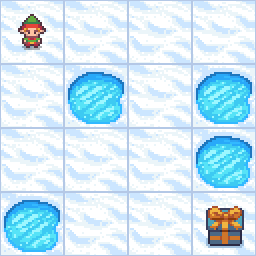

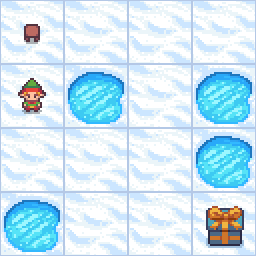

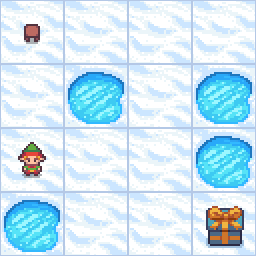

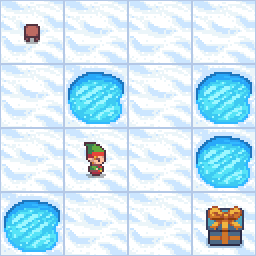

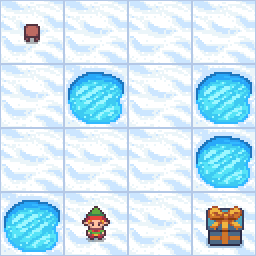

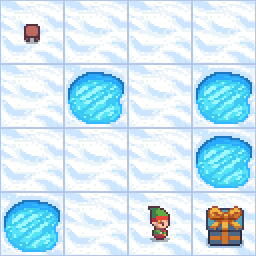

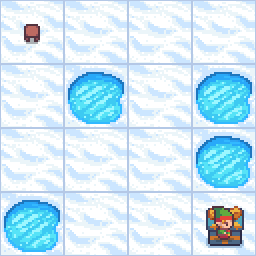

In [ ]:
def run_policy(env, policy, max_steps=30):
    state, info = env.reset()

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):
        action = policy[state]
        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        frames.append(env.render())

        if terminated or truncated:
            break

    print("Steps:", len(frames) - 1)
    print("Reward:", total_reward)

    for frame in frames:
        display(Image.fromarray(frame))

run_policy(env, policy_det)

# Part II — Now make the lake slippery

We keep **exactly the same Bellman code**.

Only the environment changes.

With `is_slippery=True`, choosing an action does not guarantee that direction.

Now Bellman's expectation really matters:

$
\sum_{s',r}P(s',r\mid s,a)[r+\gamma V(s')]
$

because one action can have several possible next states.

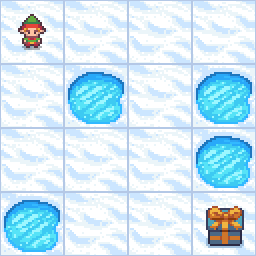

In [ ]:
slippery_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="rgb_array"
)

slippery_env.reset()
display(Image.fromarray(slippery_env.render()))

Look at the same transition from the start again.

This time one chosen action can produce several outcomes.

In [ ]:
for action, outcomes in slippery_env.unwrapped.P[0].items():
    print(f"Action {action}:")
    for outcome in outcomes:
        print("   ", outcome)

Action 0:
    (0.33333333333333337, 0, 0, False)
    (0.3333333333333333, 0, 0, False)
    (0.33333333333333337, 4, 0, False)
Action 1:
    (0.33333333333333337, 0, 0, False)
    (0.3333333333333333, 4, 0, False)
    (0.33333333333333337, 1, 0, False)
Action 2:
    (0.33333333333333337, 4, 0, False)
    (0.3333333333333333, 1, 0, False)
    (0.33333333333333337, 0, 0, False)
Action 3:
    (0.33333333333333337, 1, 0, False)
    (0.3333333333333333, 0, 0, False)
    (0.33333333333333337, 0, 0, False)


## 9. Watch value propagate again — now with uncertainty

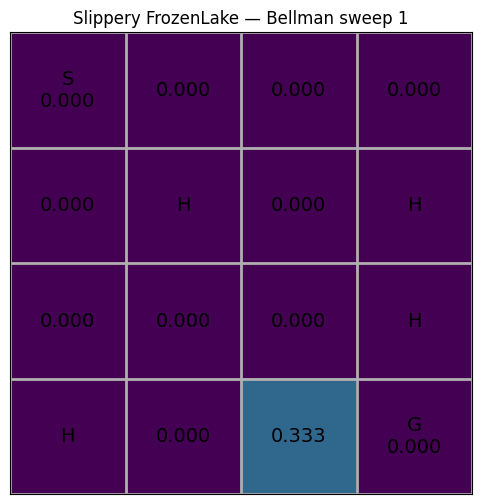

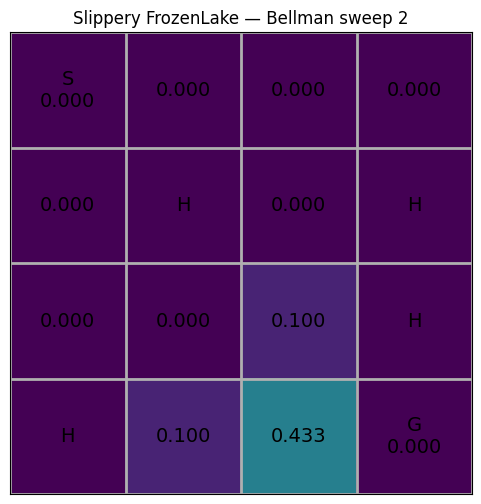

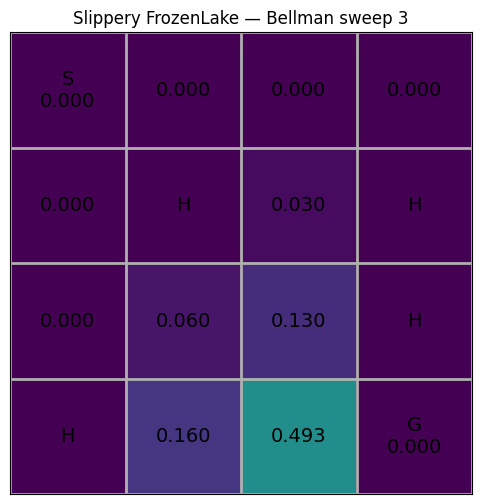

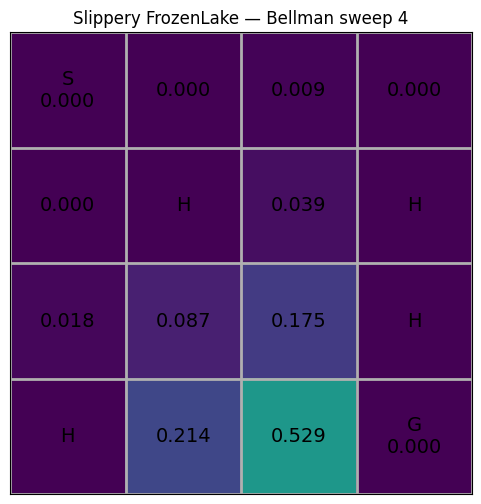

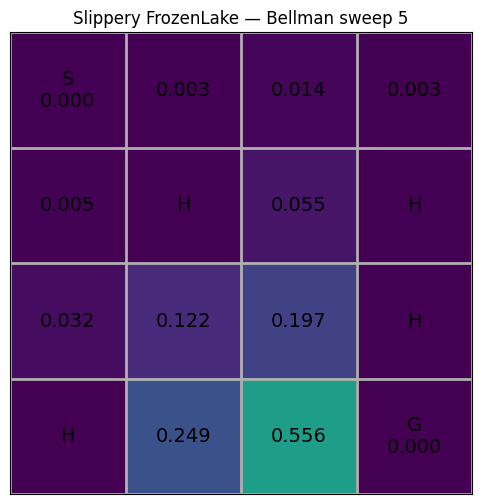

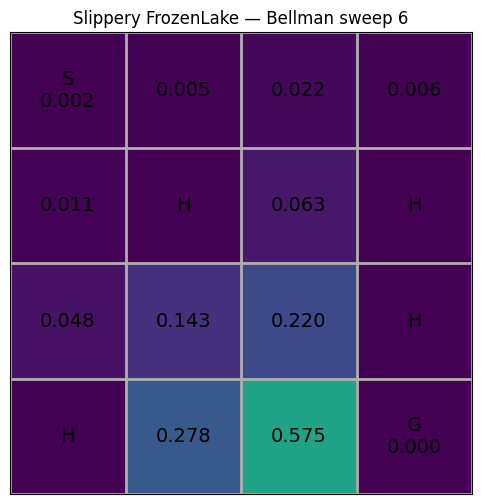

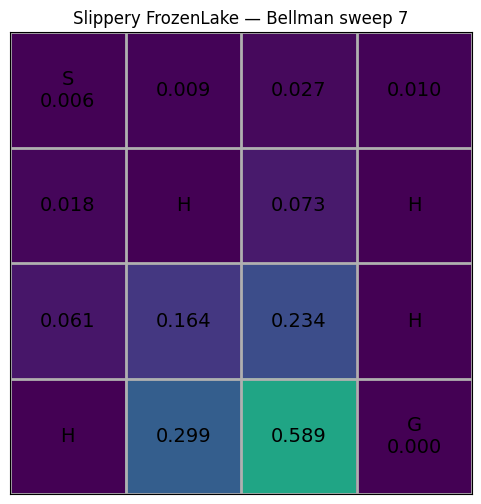

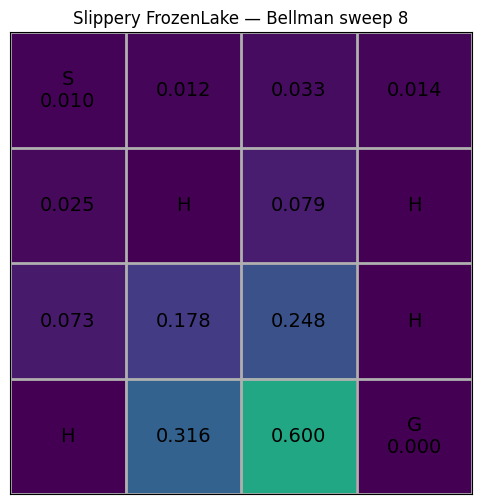

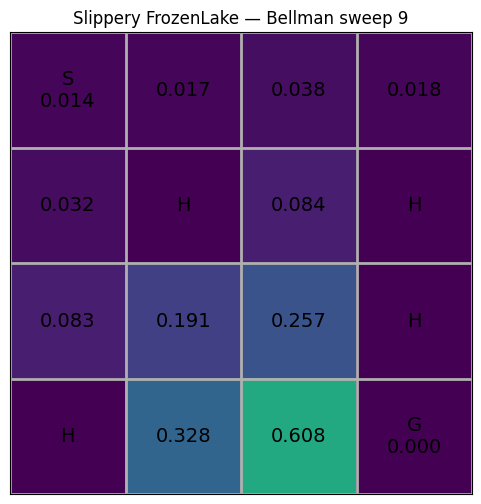

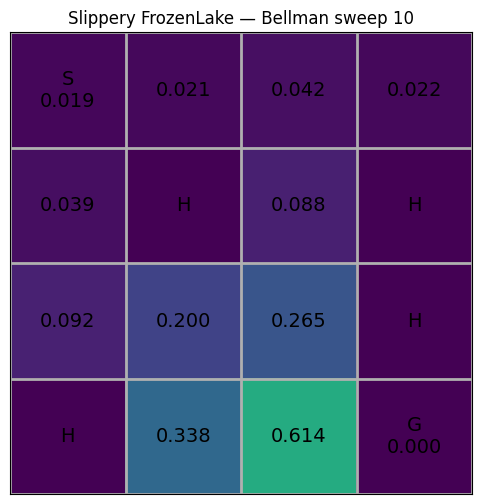

In [ ]:
V = np.zeros(slippery_env.observation_space.n)

for sweep in range(1, 11):
    V = bellman_sweep(slippery_env, V, gamma)
    show_values(V, slippery_env, f"Slippery FrozenLake — Bellman sweep {sweep}")

Notice the difference.

In the deterministic lake, values look like clean discounted paths from the goal.

In the slippery lake, a state is valuable only if the agent has a **good probability** of eventually reaching the goal while avoiding holes.

So values are no longer just powers of $\gamma$. They reflect both:

- distance to reward, and
- transition uncertainty.

Converged after 145 sweeps


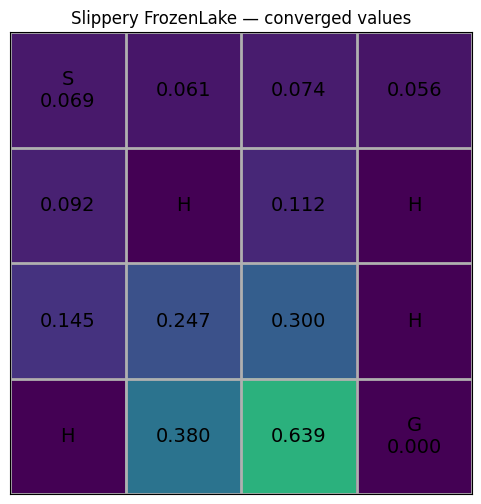

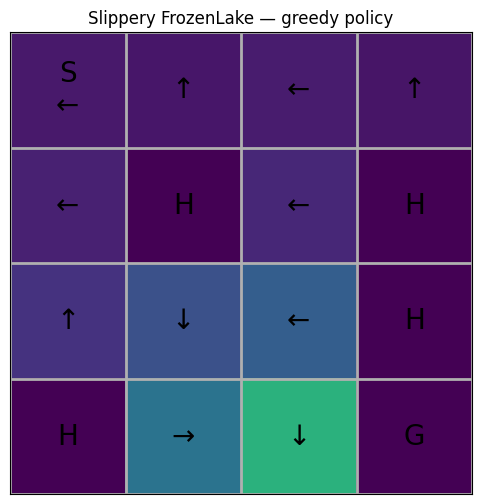

In [ ]:
V_slip, history_slip = value_iteration(slippery_env, gamma)

print("Converged after", len(history_slip) - 1, "sweeps")
show_values(V_slip, slippery_env, "Slippery FrozenLake — converged values")

policy_slip = greedy_policy(slippery_env, V_slip, gamma)
show_policy(slippery_env, policy_slip, V_slip, "Slippery FrozenLake — greedy policy")

## 10. Compare deterministic vs slippery values

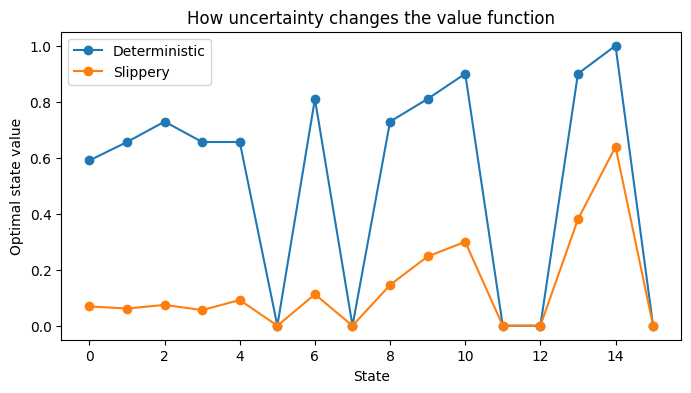

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(env.observation_space.n)

ax.plot(x, V_det, marker="o", label="Deterministic")
ax.plot(x, V_slip, marker="o", label="Slippery")

ax.set_xlabel("State")
ax.set_ylabel("Optimal state value")
ax.set_title("How uncertainty changes the value function")
ax.legend()
plt.show()

# Main idea

A value function is not magic.

It is an estimate of **future return**.

Bellman's equation lets information about future reward move backward through the state space.

### Deterministic FrozenLake

The propagation is easy to see:

$
1 \rightarrow \gamma \rightarrow \gamma^2 \rightarrow \gamma^3 \rightarrow \cdots
$

### Slippery FrozenLake

We still propagate value backward, but every action now averages over several possible outcomes.

That is why the transition probabilities \(P(s'|s,a)\) appear in the Bellman equation.

---

### Suggested classroom questions

1. Which state receives non-zero value first?
2. Why does value move only a few squares per Bellman sweep?
3. What changes when \(\gamma\) is reduced?
4. Why are slippery-state values smaller?
5. Does the greedy policy change when slipping is enabled?
6. Where exactly does uncertainty enter the Bellman update?